<a href="https://colab.research.google.com/github/nguyendiu3124-cpu/UNG-DUNG-HOC-SAU-PHAT-HIEN-HANG-GIA/blob/main/ph%C3%A2n_bi%E1%BB%87t_h%C3%A0ng_gi%E1%BA%A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Kết nối Google Drive và giải nén dữ liệu

Mã này thực hiện hai tác vụ chính:

*   Kết nối với Google Drive để truy cập các tệp được lưu trữ.
*   Giải nén tệp `.zip` chứa dữ liệu hình ảnh vào một thư mục tạm thời trên Colab (`/content/dataset`).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
# Giải nén file dữ liệu
import zipfile
import os

zip_path = '/content/drive/MyDrive/NCKH2026/code/fake-real-adidas.v4i.folder.zip' # Đường dẫn đến file trên Drive của bạn
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


 Chuẩn bị dữ liệu thô

Đoạn mã này duyệt qua các thư mục con ('train', 'test', 'valid') trong thư mục dữ liệu đã giải nén, thu thập tất cả các ảnh và phân loại chúng thành hai nhãn ('real', 'fake'). Sau đó, nó sao chép các ảnh này vào một cấu trúc thư mục phẳng (`/content/raw_data`) và tạo một DataFrame (`data_raw`) chứa đường dẫn và nhãn của từng ảnh.

In [ ]:
import os
import shutil
import pandas as pd

# Định nghĩa đường dẫn
extract_tmp = '/content/dataset' # Nơi dữ liệu gốc được giải nén
raw_path = '/content/raw_data'   # Thư mục đích để gom dữ liệu thô

# 2. Tạo thư mục đích cho Raw Data
for label in ['real', 'fake']:
    os.makedirs(os.path.join(raw_path, label), exist_ok=True)

# 3. Duyệt và gom file, đồng thời tạo list dữ liệu
data_records = []

# Duyệt qua các thư mục cũ (train, test, valid)
for split_folder in ['train', 'test', 'valid']:
    split_dir = os.path.join(extract_tmp, split_folder)
    if not os.path.exists(split_dir): continue

    for label in ['real', 'fake']:
        label_dir = os.path.join(split_dir, label)
        if not os.path.exists(label_dir): continue

        for file_name in os.listdir(label_dir):
            src_file = os.path.join(label_dir, file_name)
            dest_file = os.path.join(raw_path, label, file_name)

            # Chép file về kho Raw
            shutil.copy(src_file, dest_file)

            # Lưu vào list (CHỈ lưu path và label, KHÔNG tạo cột split)
            data_records.append({
                'image_path': dest_file,
                'label': label
            })

# 4. Tạo DataFrame và Xử lý
data_raw = pd.DataFrame(data_records)

# ĐẢM BẢO: Xóa cột split nếu nó vô tình xuất hiện từ file csv cũ hoặc quá trình gom
data_raw.drop(columns=['split'], errors='ignore', inplace=True)

print("--- HOÀN THÀNH GOM DATA ---")
print(f"Tổng số ảnh thu thập được: {len(data_raw)}")
print(f"Cấu trúc các cột hiện tại: {data_raw.columns.tolist()}")
display(data_raw.head())

--- HOÀN THÀNH GOM DATA ---
Tổng số ảnh thu thập được: 1961
Cấu trúc các cột hiện tại: ['image_path', 'label']


,image_path,label
0,/content/raw_data/real/00233_jpg.rf.fbe8d4de4f...,real
1,/content/raw_data/real/00283_jpg.rf.40b867f953...,real
2,/content/raw_data/real/00175_jpg.rf.1b18ae873c...,real
3,/content/raw_data/real/00274_jpg.rf.3ccdb8578d...,real
4,/content/raw_data/real/00311_jpg.rf.70a36e51b4...,real






 Phân tích phân bố nhãn dữ liệu

Mã này in ra kích thước của DataFrame `data_raw` và hiển thị số lượng hình ảnh cho mỗi nhãn ('real' và 'fake'). Sau đó, nó tạo một biểu đồ cột để trực quan hóa sự phân bố này, giúp chúng ta hiểu rõ về sự cân bằng giữa các lớp dữ liệu.

Shape of data_raw: (1961, 2)

Distribution of Labels:


,count
label,
real,1286
fake,675


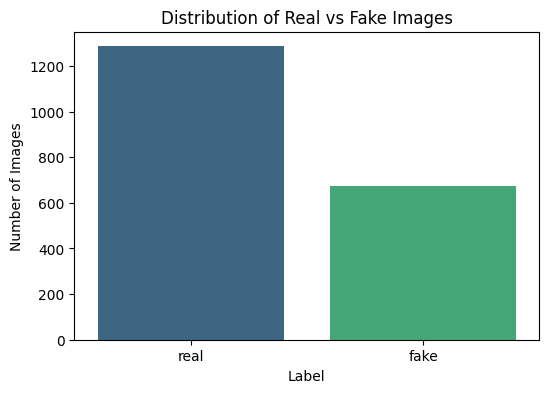

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Shape of data_raw: {data_raw.shape}")

# Distribution of labels
print("\nDistribution of Labels:")
label_counts = data_raw['label'].value_counts()
display(label_counts)

# Visualize label distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Real vs Fake Images')
plt.xlabel('Label')
plt.ylabel('Number of Images')
plt.show()

Chia tập dữ liệu thành các tập huấn luyện, kiểm định và kiểm tra

Đoạn mã này sử dụng `train_test_split` từ thư viện `sklearn.model_selection` để chia tập dữ liệu `data_raw` thành ba tập con: huấn luyện (train), kiểm định (validation) và kiểm tra (test). Việc sử dụng `stratify=data_raw['label']` đảm bảo rằng tỷ lệ giữa các lớp ('real' và 'fake') được giữ nguyên trong tất cả các tập, tránh tình trạng mất cân bằng dữ liệu trong quá trình huấn luyện và đánh giá.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Chia Train và (Test + Valid)
# Sử dụng stratify=data_raw['label'] để giữ nguyên tỷ lệ Real/Fake ở các tập
train_df, temp_df = train_test_split(
    data_raw,
    test_size=0.3,
    random_state=42,
    stratify=data_raw['label']
)

# 2. Chia tập temp thành Valid và Test (mỗi tập 15% tổng dữ liệu)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

print(f"--- KẾT QUẢ CHIA TẬP DỮ LIỆU ---")
print(f"Tập Huấn luyện (Train): {len(train_df)} mẫu")
print(f"Tập Kiểm định (Valid):  {len(val_df)} mẫu")
print(f"Tập Kiểm tra (Test):    {len(test_df)} mẫu")

# Kiểm tra lại tỷ lệ trong tập Train để đảm bảo tính khách quan
print("\nTỷ lệ nhãn trong tập Train:")
print(train_df['label'].value_counts(normalize=True))

--- KẾT QUẢ CHIA TẬP DỮ LIỆU ---
Tập Huấn luyện (Train): 1372 mẫu
Tập Kiểm định (Valid):  294 mẫu
Tập Kiểm tra (Test):    295 mẫu

Tỷ lệ nhãn trong tập Train:
label
real    0.655977
fake    0.344023
Name: proportion, dtype: float64


Cấu hình Data Augmentation và Image Data Generators

Mã này thiết lập cấu hình cho việc tăng cường dữ liệu (Data Augmentation) bằng cách sử dụng `ImageDataGenerator` của TensorFlow Keras.

*   `train_datagen` được cấu hình với các phép biến đổi như xoay, dịch chuyển, cắt, phóng to/thu nhỏ và lật ngang để tạo ra các biến thể mới của ảnh trong tập huấn luyện. Điều này giúp mô hình học được các đặc điểm tổng quát hơn và giảm thiểu overfitting.
*   `test_val_datagen` chỉ thực hiện chuẩn hóa pixel mà không áp dụng các phép biến đổi, đảm bảo dữ liệu kiểm định và kiểm tra được đánh giá một cách nhất quán.

Sau đó, các `flow_from_dataframe` được tạo để nạp dữ liệu theo lô (batch) từ các DataFrame đã chia.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Cấu hình cho tập TRAIN (Có Augmentation)=> Để AI linh hoạt hơn trong nhận diện fake ở mọi góc độ của sản phẩm
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Chuẩn hóa pixel về [0, 1]
    rotation_range=20,        # Xoay ảnh ngẫu nhiên tối đa 20 độ
    width_shift_range=0.1,    # Dịch chuyển ngang
    height_shift_range=0.1,   # Dịch chuyển dọc
    shear_range=0.1,          # Biến dạng hình học nhẹ
    zoom_range=0.2,           # Phóng to/thu nhỏ
    horizontal_flip=True,     # Lật ảnh ngang (giày trái thành giày phải)
    fill_mode='nearest'       # Lấp đầy các vùng trống sau khi xoay/dịch
)

# Cấu hình cho tập VALID và TEST (Chỉ chuẩn hóa, KHÔNG biến đổi)
test_val_datagen = ImageDataGenerator(rescale=1./255)

# Thiết lập kích thước chuẩn cho ảnh
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Tạo luồng nạp dữ liệu từ DataFrame đã chia ở bước trước
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = test_val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 1372 validated image filenames belonging to 2 classes.
Found 294 validated image filenames belonging to 2 classes.


 Hiển thị ảnh sau khi tăng cường dữ liệu

Đoạn mã này lấy một lô (batch) ảnh từ `train_generator` và hiển thị 9 ảnh đầu tiên. Điều này giúp chúng ta hình dung các phép biến đổi đã được áp dụng thông qua Data Augmentation, từ đó kiểm tra xem dữ liệu có được tăng cường như mong muốn hay không.

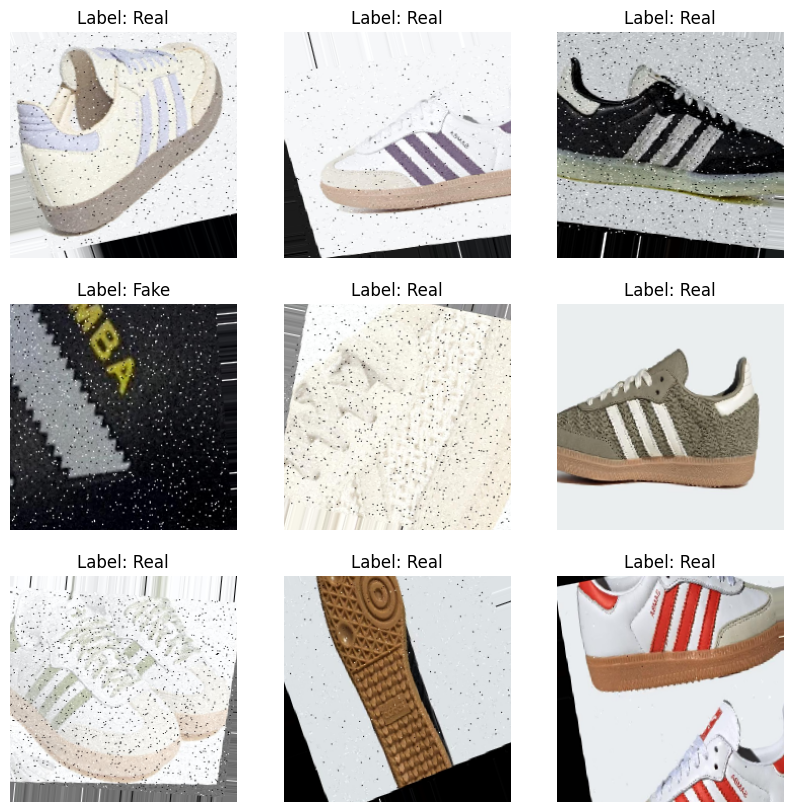

In [ ]:
import matplotlib.pyplot as plt

# Lấy thử 1 batch ảnh
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {'Real' if labels[i]==1 else 'Fake'}")
    plt.axis('off')
plt.show()

### Hàm xây dựng mô hình CNN chuyển giao học tập (Transfer Learning)

Hàm `create_model` định nghĩa cách xây dựng một mô hình phân loại hình ảnh sử dụng kiến trúc chuyển giao học tập. Nó tải một mô hình tiền huấn luyện (như ResNet50 hoặc MobileNetV2) từ `imagenet`, đóng băng các lớp nền (để tránh làm hỏng các trọng số đã học), sau đó thêm một lớp GlobalAveragePooling2D và một lớp Dense với kích hoạt sigmoid để thực hiện phân loại nhị phân (real/fake). Mô hình được biên dịch với trình tối ưu hóa 'adam' và hàm mất mát 'binary_crossentropy'.

In [ ]:
def create_model(base_arch):
    # base_arch sẽ là tf.keras.applications.ResNet50 hoặc MobileNetV2
    base_model = base_arch(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

 Kiểm tra cài đặt TensorFlow

Đoạn mã đơn giản này nhập thư viện TensorFlow và in ra thông báo xác nhận, đảm bảo rằng TensorFlow đã được cài đặt và có thể sử dụng trong môi trường hiện tại.

In [ ]:
import tensorflow as tf
print("TensorFlow imported successfully as tf.")

TensorFlow imported successfully as tf.


 Huấn luyện các mô hình MobileNetV2 và ResNet50

Mã này khởi tạo và huấn luyện hai mô hình CNN khác nhau: MobileNetV2 và ResNet50, sử dụng hàm `create_model` đã định nghĩa trước đó. Cả hai mô hình đều được huấn luyện trên `train_generator` và được kiểm định trên `val_generator` trong 10 epoch. Kết quả huấn luyện (lịch sử độ chính xác và mất mát) được lưu trữ để phân tích sau này.

In [ ]:
# Huấn luyện MobileNetV2
model_mobilenet = create_model(tf.keras.applications.MobileNetV2)
history_mobilenet = model_mobilenet.fit(train_generator, validation_data=val_generator, epochs=10)

# Huấn luyện ResNet50
model_resnet = create_model(tf.keras.applications.ResNet50)
history_resnet = model_resnet.fit(train_generator, validation_data=val_generator, epochs=10)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.7019 - loss: 0.5794 - val_accuracy: 0.7891 - val_loss: 0.4846
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 418ms/step - accuracy: 0.8010 - loss: 0.4272 - val_accuracy: 0.8503 - val_loss: 0.4045
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 415ms/step - accuracy: 0.8426 - loss: 0.3769 - val_accuracy: 0.8639 - val_loss: 0.3530
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 417ms/step - accuracy: 0.8652 - loss: 0.3235 - val_accuracy: 0.8707 - val_loss: 0.3371
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 420ms/step - accuracy: 0.8739 - loss: 0.3021 - val_accuracy: 0.8844 - val_loss: 0.3070
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 417ms/step - accuracy: 0.8834 - loss: 0.2870 - val_accuracy: 0.8912 - val_loss: 0.2966
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 420ms/step - accuracy: 0.8783 - loss: 0.2831 - val_accuracy: 0.8946 - val_loss: 0.2890
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 418ms/ste

In [ ]:
# Phụ để lưu mô hình
# Huấn luyện ResNet50
model_resnet = create_model(tf.keras.applications.ResNet50)
history_resnet = model_resnet.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 45s 730ms/step - accuracy: 0.6633 - loss: 0.6359 - val_accuracy: 0.7041 - val_loss: 0.6253
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 480ms/step - accuracy: 0.6829 - loss: 0.6218 - val_accuracy: 0.7075 - val_loss: 0.5998
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 484ms/step - accuracy: 0.6968 - loss: 0.6096 - val_accuracy: 0.7211 - val_loss: 0.5933
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 474ms/step - accuracy: 0.7041 - loss: 0.6002 - val_accuracy: 0.7279 - val_loss: 0.5889
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 486ms/step - accuracy: 0.7012 - loss: 0.5981 - val_accuracy: 0.7279 - val_loss: 0.5829
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 473ms/step - accuracy: 0.7085 - loss: 0.5898 - val_accuracy: 0.7381 - val_loss: 0.5890
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 477ms/step - accuracy: 0.7136 - loss: 0.5842 - val_accuracy: 0.7415 - val_loss: 0.5946
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 482ms/step - accuracy: 0.7187 - loss: 0.5858 - val_accu

In [ ]:
resnet_path = "/content/drive/MyDrive/NCKH2026/resnet50_best_model.h5"

model_resnet.save(resnet_path)

print("Đã lưu ResNet50 tại:", resnet_path)

Đã lưu ResNet50 tại: /content/drive/MyDrive/NCKH2026/resnet50_best_model.h5


In [ ]:
model_resnet = tf.keras.models.load_model(resnet_path)

print("Đã load ResNet50 thành công.")

Đã load ResNet50 thành công.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
test_generator = test_val_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 295 validated image filenames belonging to 2 classes.


In [ ]:
print("===== ĐÁNH GIÁ MOBILE NET V2 =====")
test_loss_mobilenet, test_acc_mobilenet = model_mobilenet.evaluate(test_generator, verbose=1)
print(f"MobileNetV2 - Test Loss: {test_loss_mobilenet:.4f}")
print(f"MobileNetV2 - Test Accuracy: {test_acc_mobilenet:.4f}")

print("\n===== ĐÁNH GIÁ RESNET50 =====")
test_loss_resnet, test_acc_resnet = model_resnet.evaluate(test_generator, verbose=1)
print(f"ResNet50 - Test Loss: {test_loss_resnet:.4f}")
print(f"ResNet50 - Test Accuracy: {test_acc_resnet:.4f}")

===== ĐÁNH GIÁ MOBILE NET V2 =====
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8746 - loss: 0.2923
MobileNetV2 - Test Loss: 0.2923
MobileNetV2 - Test Accuracy: 0.8746

===== ĐÁNH GIÁ RESNET50 =====
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 378ms/step - accuracy: 0.6780 - loss: 0.6120
ResNet50 - Test Loss: 0.6120
ResNet50 - Test Accuracy: 0.6780


In [ ]:
test_generator.reset()
y_prob_mobilenet = model_mobilenet.predict(test_generator, verbose=1)

test_generator.reset()
y_prob_resnet = model_resnet.predict(test_generator, verbose=1)

# Vì class_mode='binary' nên đầu ra thường là xác suất 1 cột
y_pred_mobilenet = (y_prob_mobilenet > 0.5).astype(int).reshape(-1)
y_pred_resnet = (y_prob_resnet > 0.5).astype(int).reshape(-1)

# Nhãn thật
y_true = test_generator.classes

# Tên lớp
class_names = list(test_generator.class_indices.keys())
print("Class mapping:", test_generator.class_indices)

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 524ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 514ms/step
Class mapping: {'fake': 0, 'real': 1}


In [ ]:
acc_mobilenet = accuracy_score(y_true, y_pred_mobilenet)
acc_resnet = accuracy_score(y_true, y_pred_resnet)

print("\n===== ACCURACY TÍNH TỪ DỰ ĐOÁN =====")
print(f"MobileNetV2 Accuracy: {acc_mobilenet:.4f}")
print(f"ResNet50 Accuracy:    {acc_resnet:.4f}")


===== ACCURACY TÍNH TỪ DỰ ĐOÁN =====
MobileNetV2 Accuracy: 0.8746
ResNet50 Accuracy:    0.6780


In [ ]:
print("\n===== CLASSIFICATION REPORT: MobileNetV2 =====")
print(classification_report(y_true, y_pred_mobilenet, target_names=class_names, digits=4))

print("\n===== CLASSIFICATION REPORT: ResNet50 =====")
print(classification_report(y_true, y_pred_resnet, target_names=class_names, digits=4))


===== CLASSIFICATION REPORT: MobileNetV2 =====
              precision    recall  f1-score   support

        fake     0.8652    0.7549    0.8063       102
        real     0.8786    0.9378    0.9073       193

    accuracy                         0.8746       295
   macro avg     0.8719    0.8464    0.8568       295
weighted avg     0.8740    0.8746    0.8724       295


===== CLASSIFICATION REPORT: ResNet50 =====
              precision    recall  f1-score   support

        fake     0.6522    0.1471    0.2400       102
        real     0.6801    0.9585    0.7957       193

    accuracy                         0.6780       295
   macro avg     0.6662    0.5528    0.5178       295
weighted avg     0.6705    0.6780    0.6036       295



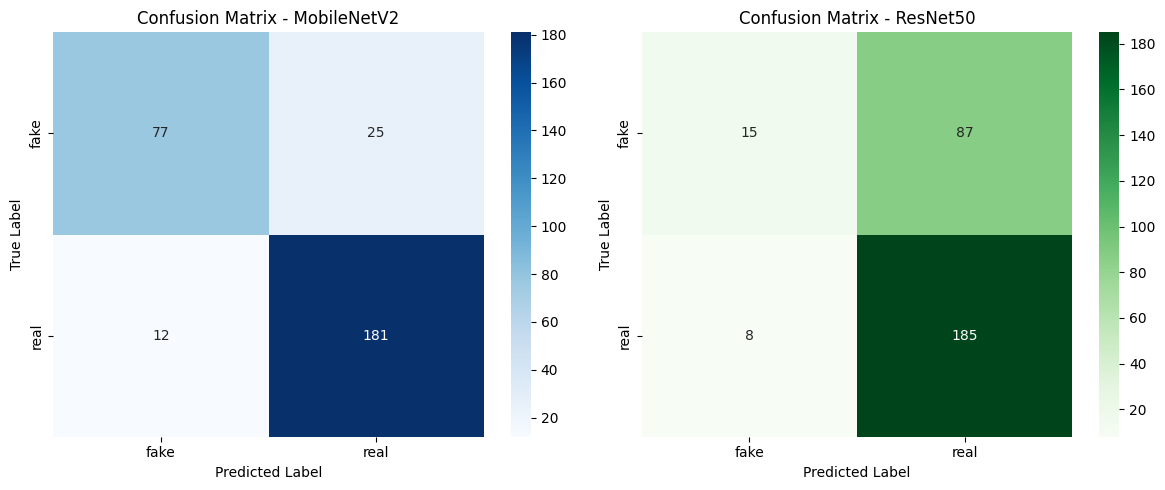

In [ ]:
cm_mobilenet = confusion_matrix(y_true, y_pred_mobilenet)
cm_resnet = confusion_matrix(y_true, y_pred_resnet)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm_mobilenet,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.subplot(1, 2, 2)
sns.heatmap(
    cm_resnet,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - ResNet50")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

Đánh giá và trực quan hóa kết quả huấn luyện

Đoạn mã này in ra độ chính xác và hàm mất mát cuối cùng của cả MobileNetV2 và ResNet50 trên tập kiểm định. Sau đó, nó tạo hai cặp biểu đồ (độ chính xác và mất mát) cho mỗi mô hình, hiển thị sự thay đổi của các chỉ số này qua các epoch huấn luyện trên cả tập huấn luyện và tập kiểm định. Điều này giúp đánh giá hiệu suất và phát hiện các vấn đề như overfitting hoặc underfitting.


--- KẾT QUẢ HUẤN LUYỆN ---

MobileNetV2:
  Độ chính xác trên tập kiểm định cuối cùng: 0.8878
  Hàm mất mát trên tập kiểm định cuối cùng: 0.3071

ResNet50:
  Độ chính xác trên tập kiểm định cuối cùng: 0.7483
  Hàm mất mát trên tập kiểm định cuối cùng: 0.5664


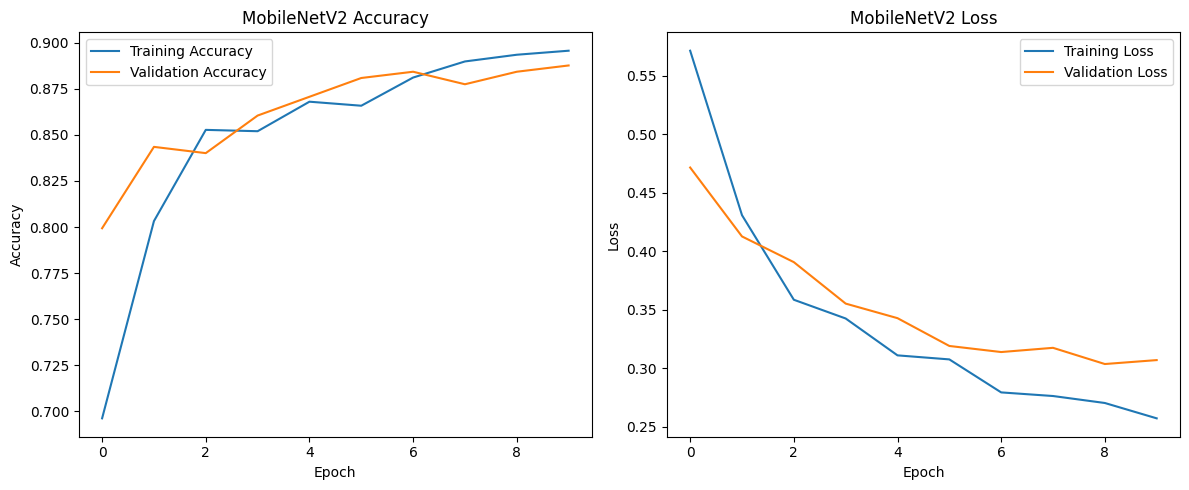

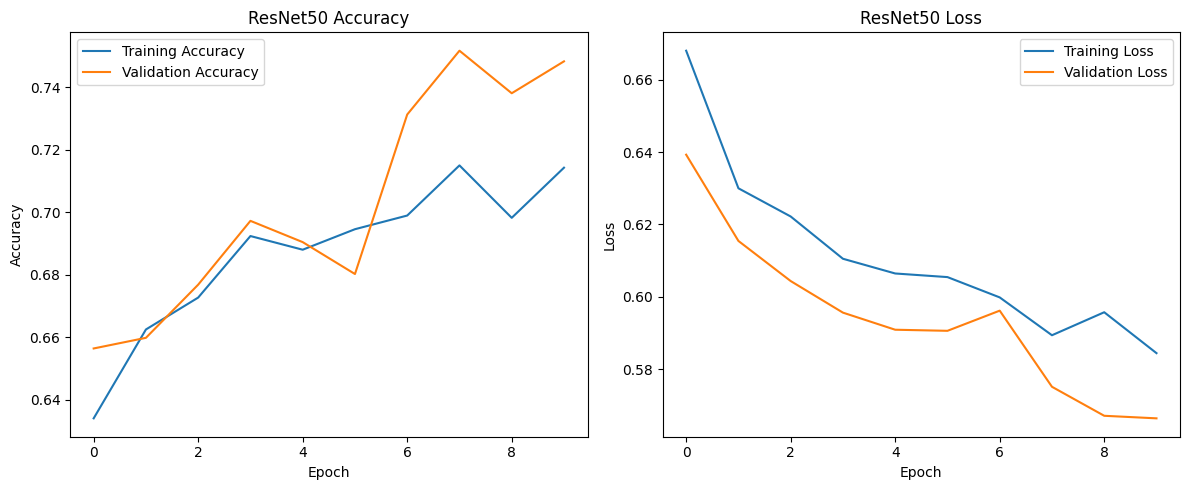

In [ ]:

# --- Đọc kết quả của hai mô hình ---
import matplotlib.pyplot as plt

print("\n--- KẾT QUẢ HUẤN LUYỆN ---")

# Kết quả MobileNetV2
print("\nMobileNetV2:")
val_acc_mobilenet = history_mobilenet.history['val_accuracy'][-1]
val_loss_mobilenet = history_mobilenet.history['val_loss'][-1]
print(f"  Độ chính xác trên tập kiểm định cuối cùng: {val_acc_mobilenet:.4f}")
print(f"  Hàm mất mát trên tập kiểm định cuối cùng: {val_loss_mobilenet:.4f}")

# Kết quả ResNet50
print("\nResNet50:")
val_acc_resnet = history_resnet.history['val_accuracy'][-1]
val_loss_resnet = history_resnet.history['val_loss'][-1]
print(f"  Độ chính xác trên tập kiểm định cuối cùng: {val_acc_resnet:.4f}")
print(f"  Hàm mất mát trên tập kiểm định cuối cùng: {val_loss_resnet:.4f}")


# Vẽ biểu đồ Accuracy và Loss cho MobileNetV2
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mobilenet.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mobilenet.history['loss'], label='Training Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Vẽ biểu đồ Accuracy và Loss cho ResNet50
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('ResNet50 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### So sánh hiệu suất giữa MobileNetV2 và ResNet50 trên tập kiểm định

Hàm `plot_comparison` tạo ra các biểu đồ so sánh độ chính xác và hàm mất mát trên tập kiểm định giữa MobileNetV2 và ResNet50. Điều này giúp trực quan hóa mô hình nào học tốt hơn và ổn định hơn trong giai đoạn huấn luyện ban đầu.

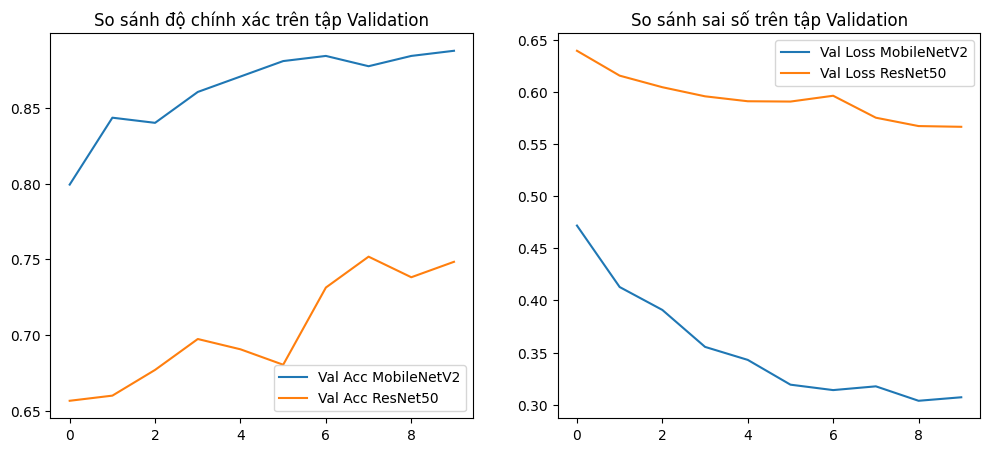

In [ ]:
def plot_comparison(h1, h2, name1, name2):
    plt.figure(figsize=(12, 5))

    # So sánh Độ chính xác (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(h1.history['val_accuracy'], label=f'Val Acc {name1}')
    plt.plot(h2.history['val_accuracy'], label=f'Val Acc {name2}')
    plt.title('So sánh độ chính xác trên tập Validation')
    plt.legend()

    # So sánh Sai số (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(h1.history['val_loss'], label=f'Val Loss {name1}')
    plt.plot(h2.history['val_loss'], label=f'Val Loss {name2}')
    plt.title('So sánh sai số trên tập Validation')
    plt.legend()

    plt.show()

plot_comparison(history_mobilenet, history_resnet, "MobileNetV2", "ResNet50")

### Lưu mô hình có hiệu suất tốt nhất

Mã này so sánh độ chính xác trên tập kiểm tra của MobileNetV2 và ResNet50 để xác định mô hình nào hoạt động tốt nhất. Sau đó, nó lưu mô hình chiến thắng (cùng với tên file tương ứng) vào Google Drive để có thể sử dụng lại sau này mà không cần huấn luyện lại.

In [ ]:
import os

# Xác định mô hình tốt nhất dựa trên độ chính xác trên tập test
if test_acc_mob > test_acc_res:
    best_model = model_mobilenet
    model_name = 'mobilenetv2_finetuned_best_model.h5'
    print(f"MobileNetV2 ({test_acc_mob:.2f}%) hoạt động tốt hơn ResNet50 ({test_acc_res:.2f}%). Sẽ lưu MobileNetV2.")
else:
    best_model = model_resnet
    model_name = 'resnet50_best_model.h5'
    print(f"ResNet50 ({test_acc_res:.2f}%) hoạt động tốt hơn MobileNetV2 ({test_acc_mob:.2f}%). Sẽ lưu ResNet50.")

# Lưu mô hình
model_save_path = os.path.join('/content/drive/MyDrive/NCKH2026', model_name)
best_model.save(model_save_path)
print(f"Mô hình tốt nhất đã được lưu tại: {model_save_path}")

MobileNetV2 (0.87%) hoạt động tốt hơn ResNet50 (0.73%). Sẽ lưu MobileNetV2.
Mô hình tốt nhất đã được lưu tại: /content/drive/MyDrive/NCKH2026/mobilenetv2_finetuned_best_model.h5


### Mô hình ViT

Để sử dụng các tham số mới (`batch_size`, `transforms.Resize`, `num_workers`), chúng ta cần định nghĩa lại các phép biến đổi ảnh và khởi tạo lại các `ImageDataset` và `DataLoader`.

In [ ]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import pandas as pd

# Định nghĩa các tham số mới
BATCH_SIZE = 4
NUM_WORKERS = 0 # Đặt về 0 nếu gặp lỗi với đa luồng trên Colab hoặc Windows
IMG_RESIZE = (224, 224)

# Định nghĩa các phép biến đổi cho tập huấn luyện và kiểm định
train_transform = transforms.Compose([
    transforms.Resize(IMG_RESIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize(IMG_RESIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Định nghĩa lại ImageDataset class
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.label_map = {'fake': 0, 'real': 1}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        image = Image.open(img_path).convert('RGB')
        label_str = self.dataframe.iloc[idx]['label']
        label = torch.tensor(self.label_map[label_str], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)
        return image, label

# Khởi tạo lại Datasets
train_dataset_vit = ImageDataset(train_df, transform=train_transform)
val_dataset_vit = ImageDataset(val_df, transform=val_test_transform)
test_dataset_vit = ImageDataset(test_df, transform=val_test_transform)

# Khởi tạo lại DataLoaders với các tham số mới
train_loader = DataLoader(
    train_dataset_vit,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset_vit,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset_vit,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"DataLoaders đã được tạo lại với Batch Size: {BATCH_SIZE}, Num Workers: {NUM_WORKERS}, Resize: {IMG_RESIZE}")

DataLoaders đã được tạo lại với Batch Size: 4, Num Workers: 0, Resize: (224, 224)


### Huấn luyện mô hình Vision Transformer (ViT) với các tham số mới

Đoạn mã này thực hiện quá trình huấn luyện mô hình Vision Transformer sử dụng các `DataLoader` đã được cấu hình với `batch_size = 4`, `Resize((224, 224))` và `num_workers = 0`.

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import vit_b_16

# ===== DEVICE =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===== MODEL =====
model_vit = vit_b_16(weights="IMAGENET1K_V1")

# sửa head → binary classification (1 output)
model_vit.heads = nn.Linear(model_vit.heads.head.in_features, 1)

model_vit = model_vit.to(device)

# ===== FREEZE BACKBONE (để không bị lag) =====
for param in model_vit.parameters():
    param.requires_grad = False

for param in model_vit.heads.parameters():
    param.requires_grad = True

# ===== LOSS =====
criterion = nn.BCEWithLogitsLoss()

# ===== OPTIMIZER =====
optimizer = torch.optim.Adam(model_vit.heads.parameters(), lr=1e-4)

print("Model, Loss, Optimizer đã sẵn sàng!")

Device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 243MB/s]


Model, Loss, Optimizer đã sẵn sàng!


In [ ]:
from tqdm import tqdm
import torch
import os

# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_epochs = 10
best_val_acc = 0.0  # best acc

#đường dẫn lưu model
save_path = "/content/drive/MyDrive/NCKH2026/best_vit_model.pth"

history_vit = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print(f"🚀 Bắt đầu training trên {device}")

for epoch in range(num_epochs):

    # TRAIN
    model_vit.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Train)"):
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()

        outputs = model_vit(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    history_vit['train_loss'].append(epoch_train_loss)
    history_vit['train_acc'].append(epoch_train_acc)

    # VALIDATION
    model_vit.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Validation)"):
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model_vit(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val

    history_vit['val_loss'].append(epoch_val_loss)
    history_vit['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # SAVE BEST MODEL
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model_vit.state_dict(), save_path)
        print(f"Saved BEST model at epoch {epoch+1} (Val Acc: {epoch_val_acc:.4f})")

print("Huấn luyện Vision Transformer hoàn tất.")
print(f"Model tốt nhất được lưu tại: {save_path}")

🚀 Bắt đầu training trên cuda


Epoch 1/10 (Validation): 100%|██████████| 74/74 [00:02<00:00, 25.89it/s]


Epoch 1/10 | Train Loss: 0.5875 | Train Acc: 0.6589 | Val Loss: 0.5105 | Val Acc: 0.7177
Saved BEST model at epoch 1 (Val Acc: 0.7177)


Epoch 2/10 (Validation): 100%|██████████| 74/74 [00:02<00:00, 25.57it/s]


Epoch 2/10 | Train Loss: 0.4808 | Train Acc: 0.7507 | Val Loss: 0.4376 | Val Acc: 0.8027
Saved BEST model at epoch 2 (Val Acc: 0.8027)


...

Epoch 8/10 | Train Loss: 0.2730 | Train Acc: 0.9169 | Val Loss: 0.2744 | Val Acc: 0.9082


Epoch 9/10 (Validation): 100%|██████████| 74/74 [00:02<00:00, 26.49it/s]


Epoch 9/10 | Train Loss: 0.2578 | Train Acc: 0.9242 | Val Loss: 0.2619 | Val Acc: 0.9150
Saved BEST model at epoch 9 (Val Acc: 0.9150)


Epoch 10/10 (Validation): 100%|██████████| 74/74 [00:02<00:00, 26.09it/s]


Epoch 10/10 | Train Loss: 0.2434 | Train Acc: 0.9264 | Val Loss: 0.2506 | Val Acc: 0.9184
Saved BEST model at epoch 10 (Val Acc: 0.9184)
Huấn luyện Vision Transformer hoàn tất.
Model tốt nhất được lưu tại: /content/drive/MyDrive/NCKH2026/best_vit_model.pth


# Huấn luyện mô hình và Lưu mô hình cho kết quả tốt nhất

#Đánh giá hiệu xuất mô hình ViT

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch

model_vit.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model_vit(images)
        preds = (torch.sigmoid(outputs) > 0.5).int().cpu().numpy()

        y_pred.extend(preds.flatten())
        y_true.extend(labels.numpy())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))

Accuracy: 0.9152542372881356

Confusion Matrix:
 [[ 93   9]
 [ 16 177]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.91      0.88       102
         1.0       0.95      0.92      0.93       193

    accuracy                           0.92       295
   macro avg       0.90      0.91      0.91       295
weighted avg       0.92      0.92      0.92       295



In [ ]:
import matplotlib.pyplot as plt

plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.title("Accuracy")
plt.show()

NameError: name 'history' is not defined

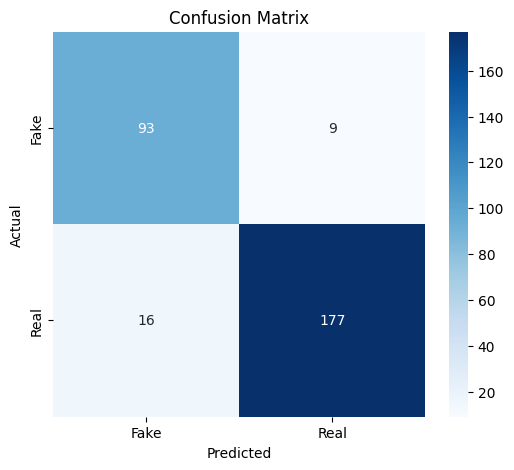

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#So sánh hiệu suất 2 mô hình

In [ ]:
# ViT Prediction
model_vit.eval()

vit_preds = []
vit_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model_vit(images)
        preds = (torch.sigmoid(outputs) > 0.5).int().cpu().numpy()

        vit_preds.extend(preds.flatten())
        vit_true.extend(labels.numpy())
# MobileNet Prediction
predicted_classes = (predictions > 0.5).astype(int)
true_classes = test_generator.labels
# TÍNH ACCURACY
from sklearn.metrics import accuracy_score

acc_mob = accuracy_score(true_classes, predicted_classes)
acc_vit = accuracy_score(vit_true, vit_preds)

print("MobileNetV2 (Fine-tuned):", acc_mob)
print("Vision Transformer:", acc_vit)
#BẢNG SO SÁNH
import pandas as pd
df_compare = pd.DataFrame({
    "Model": ["MobileNetV2 (Fine-tuned)", "Vision Transformer"],
    "Accuracy": [acc_mob, acc_vit]
})

df_compare

MobileNetV2 (Fine-tuned): 0.8745762711864407
Vision Transformer: 0.9152542372881356


,Model,Accuracy
0,MobileNetV2 (Fine-tuned),0.874576
1,Vision Transformer,0.915254


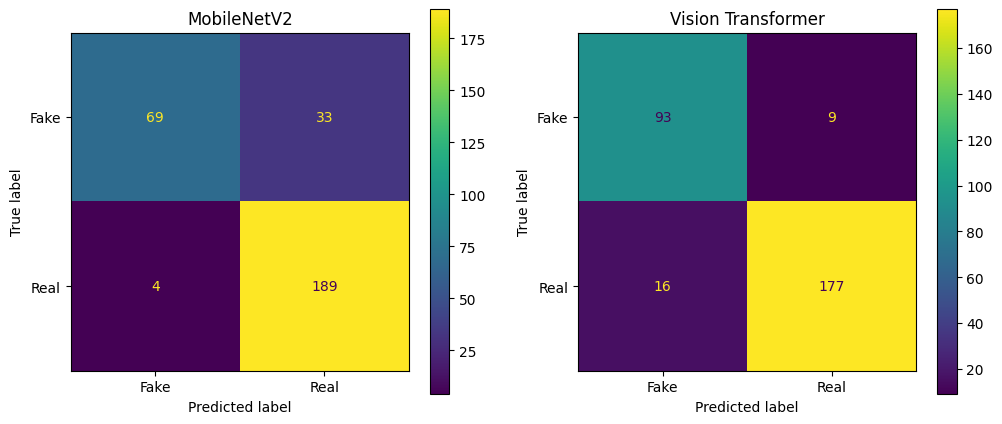

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_mob = confusion_matrix(true_classes, predicted_classes)
cm_vit = confusion_matrix(vit_true, vit_preds)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay(cm_mob, display_labels=["Fake","Real"]).plot(ax=ax[0])
ax[0].set_title("MobileNetV2")

ConfusionMatrixDisplay(cm_vit, display_labels=["Fake","Real"]).plot(ax=ax[1])
ax[1].set_title("Vision Transformer")

plt.show()

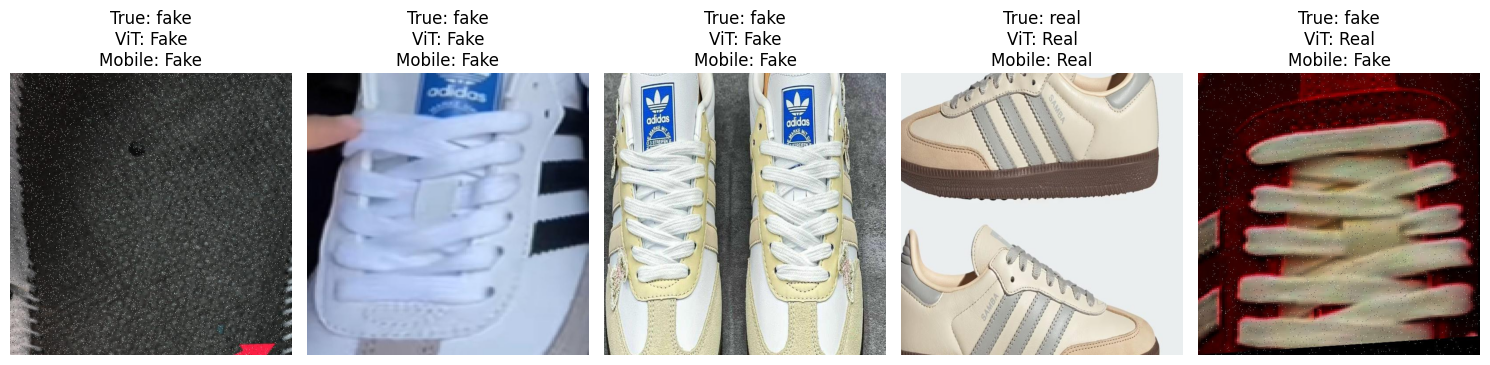

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import torch
import numpy as np

#LẤY NGẪU NHIÊN 5 ẢNH
sample_df = test_df.sample(5).reset_index(drop=True)

#TRANSFORM CHO ViT
from torchvision import transforms

vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

#LOOP QUA 5 ẢNH
plt.figure(figsize=(15,5))

for i in range(5):
    img_path = sample_df.loc[i, 'image_path']
    true_label = sample_df.loc[i, 'label']

    #LOAD IMAGE
    img = Image.open(img_path).convert("RGB")

    #PREDICT VIT
    vit_img = vit_transform(img).unsqueeze(0).to(device)

    model_vit.eval()
    with torch.no_grad():
        vit_out = model_vit(vit_img)
        vit_pred = torch.sigmoid(vit_out).item()
        vit_label = "Real" if vit_pred > 0.5 else "Fake"

    # PREDICT MOBILENET
    img_tf = img.resize((224, 224))
    img_tf = np.array(img_tf) / 255.0
    img_tf = np.expand_dims(img_tf, axis=0)

    mob_pred = model_mobilenet.predict(img_tf, verbose=0)[0][0]
    mob_label = "Real" if mob_pred > 0.5 else "Fake"

    #HIỂN THỊ
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"True: {true_label}\n"
        f"ViT: {vit_label}\n"
        f"Mobile: {mob_label}"
    )

plt.tight_layout()
plt.show()

In [ ]:
import random
import pandas as pd
from PIL import Image
import torch
import numpy as np
from torchvision import transforms
import matplotlib.pyplot as plt

# ===== LẤY 5 ẢNH NGẪU NHIÊN =====
sample_df = test_df.sample(5).reset_index(drop=True)

# ===== TRANSFORM ViT =====
vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

results = []

# ===== DỰ ĐOÁN =====
for i in range(len(sample_df)):
    img_path = sample_df.loc[i, 'image_path']
    true_label = sample_df.loc[i, 'label']

    img = Image.open(img_path).convert("RGB")

    # ===== ViT =====
    vit_img = vit_transform(img).unsqueeze(0).to(device)
    model_vit.eval()
    with torch.no_grad():
        vit_out = model_vit(vit_img)
        vit_pred = torch.sigmoid(vit_out).item()
        vit_label = "Real" if vit_pred > 0.5 else "Fake"

    # ===== MobileNet =====
    img_tf = img.resize((224, 224))
    img_tf = np.array(img_tf) / 255.0
    img_tf = np.expand_dims(img_tf, axis=0)

    mob_pred = model_mobilenet.predict(img_tf, verbose=0)[0][0]
    mob_label = "Real" if mob_pred > 0.5 else "Fake"

    results.append({
        "image_path": img_path,
        "ViT": vit_label,
        "MobileNetV2": mob_label,
        "True": true_label
    })

# ===== TẠO DATAFRAME =====
df_results = pd.DataFrame(results)

print(df_results)

                                          image_path   ViT MobileNetV2  True
0  /content/raw_data/fake/fake85_jpg.rf.79c65b151...  Fake        Fake  fake
1  /content/raw_data/real/00247_jpg.rf.4e79508d8b...  Real        Real  real
2  /content/raw_data/real/00240_jpg.rf.1a99b5883b...  Real        Real  real
3  /content/raw_data/real/00217_jpg.rf.9fbe6572b0...  Real        Real  real
4  /content/raw_data/real/real_20_PNG.rf.b570dacf...  Real        Real  real


In [ ]:
prob_fake = 1 - prob_real


NameError: name 'prob_real' is not defined

# Áp dụng với dl thu thập được

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Khai báo thư viện


In [ ]:
import os
import torch
import timm
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

Đọc dữ liệu



In [ ]:
test_root = "/content/drive/MyDrive/NCKH2026/code/Test_giay"

records = []

for label_name in ["Fake", "Real"]:
    folder = os.path.join(test_root, label_name)
    if not os.path.exists(folder):
        continue

    for file_name in os.listdir(folder):
        file_path = os.path.join(folder, file_name)
        if os.path.isfile(file_path):
            records.append({
                "image_path": file_path,
                "label": label_name,
                "product": "giày",
                "set": "test"
            })

df_test_giay = pd.DataFrame(records)
df_test_giay.head()

,image_path,label,product,set
0,/content/drive/MyDrive/NCKH2026/code/Test_giay...,Fake,giày,test
1,/content/drive/MyDrive/NCKH2026/code/Test_giay...,Fake,giày,test
2,/content/drive/MyDrive/NCKH2026/code/Test_giay...,Fake,giày,test
3,/content/drive/MyDrive/NCKH2026/code/Test_giay...,Fake,giày,test
4,/content/drive/MyDrive/NCKH2026/code/Test_giay...,Fake,giày,test


In [ ]:
label_map = {
    "Fake": 0,
    "Real": 1,
    "fake": 0,
    "real": 1
}

df_test_giay["label"] = df_test_giay["label"].map(label_map)
print(df_test_giay["label"].value_counts(dropna=False))

label
1    62
0    59
Name: count, dtype: int64


Xử lý dữ liệu



In [ ]:
class ProductDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["image_path"]
        label = row["label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
test_dataset_giay = ProductDataset(df_test_giay, transform=test_transform)
test_loader_giay = DataLoader(test_dataset_giay, batch_size=32, shuffle=False, num_workers=0)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_vit = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=1
).to(device)

Áp dụng mô hình tốt nhất

In [ ]:
import torch
from torchvision.models import vit_b_16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_vit = vit_b_16(weights=None)
model_vit.heads = torch.nn.Linear(model_vit.hidden_dim, 1)
model_vit = model_vit.to(device)

model_path = "/content/drive/MyDrive/NCKH2026/best_vit_model.pth"
state_dict = torch.load(model_path, map_location=device)

model_vit.load_state_dict(state_dict)
model_vit.eval()

print("Đã load mô hình thành công.")

Đã load mô hình thành công.


In [ ]:
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader_giay:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        outputs = model_vit(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_probs.extend(probs.cpu().numpy().flatten().tolist())
        all_preds.extend(preds.cpu().numpy().flatten().astype(int).tolist())
        all_labels.extend(labels.cpu().numpy().flatten().astype(int).tolist())

Đánh giá kết quả

In [ ]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["fake", "real"]))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Accuracy : 0.8842975206611571
Precision: 0.9444444444444444
Recall   : 0.8225806451612904
F1-score : 0.8793103448275862

Classification Report:
              precision    recall  f1-score   support

        fake       0.84      0.95      0.89        59
        real       0.94      0.82      0.88        62

    accuracy                           0.88       121
   macro avg       0.89      0.89      0.88       121
weighted avg       0.89      0.88      0.88       121


Confusion Matrix:
[[56  3]
 [11 51]]


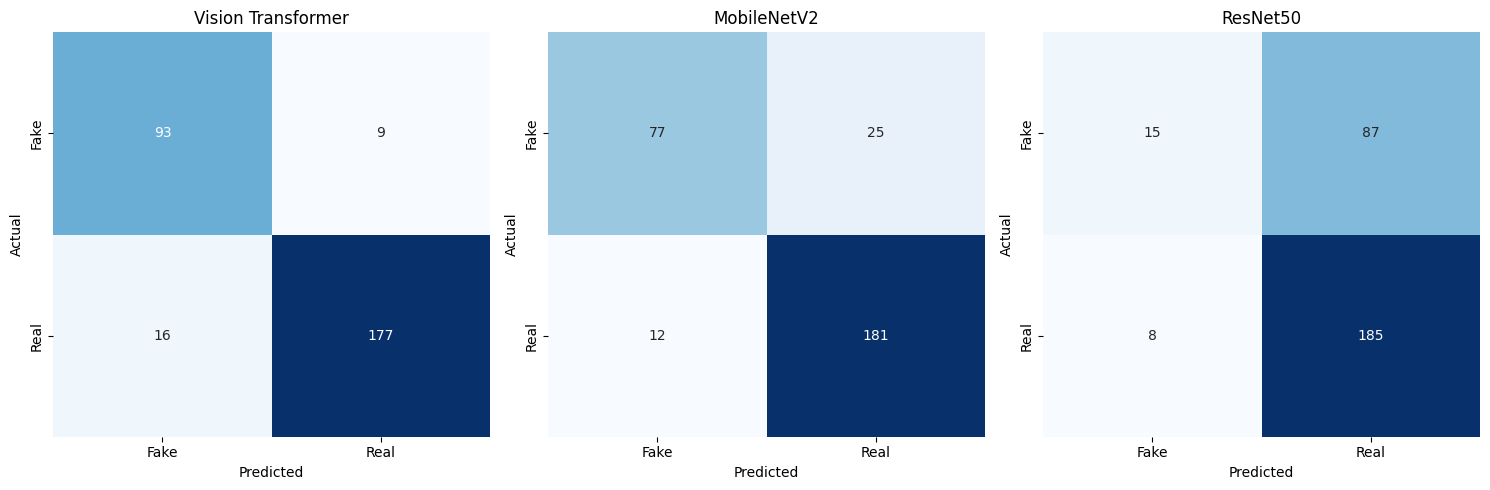

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrices
cm_vit = np.array([[93, 9],
                   [16, 177]])

cm_mobilenet = np.array([[77, 25],
                         [12, 181]])

cm_resnet = np.array([[15, 87],
                      [8, 185]])

# Tạo figure với 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Danh sách để lặp
cms = [cm_vit, cm_mobilenet, cm_resnet]
titles = ["Vision Transformer", "MobileNetV2", "ResNet50"]

# Vẽ từng confusion matrix
for i, ax in enumerate(axes):
    sns.heatmap(cms[i], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Fake", "Real"],
                yticklabels=["Fake", "Real"],
                ax=ax)
    ax.set_title(titles[i])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

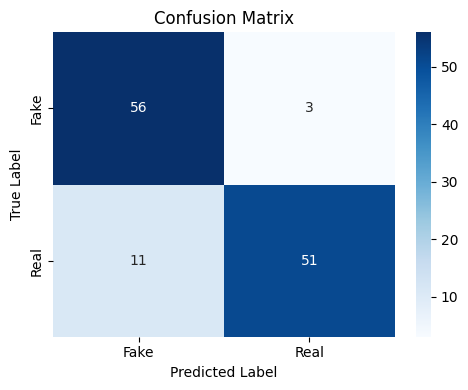

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix
cm = np.array([[56, 3],
               [11, 51]])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [ ]:
all_preds = []
all_labels = []
all_probs = []

model_vit.eval()

with torch.no_grad():
    for images, labels in test_loader_giay:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        outputs = model_vit(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_probs.extend(probs.cpu().numpy().flatten().tolist())
        all_preds.extend(preds.cpu().numpy().flatten().astype(int).tolist())
        all_labels.extend(labels.cpu().numpy().flatten().astype(int).tolist())

print("Số lượng xác suất:", len(all_probs))
print("Số lượng nhãn thật:", len(all_labels))
print("Số lượng dự đoán:", len(all_preds))

Số lượng xác suất: 121
Số lượng nhãn thật: 121
Số lượng dự đoán: 121


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    auc,
    confusion_matrix,
    classification_report
)

# Nhãn gốc: Fake = 0, Real = 1
y_true = np.array(all_labels).astype(int)

# all_probs là xác suất mô hình dự đoán lớp Real
prob_real = np.array(all_probs).astype(float)

# Đưa Fake thành positive class
y_true_fake = (y_true == 0).astype(int)

# Xác suất thuộc lớp Fake
prob_fake = 1 - prob_real

# Dự đoán Fake theo threshold 0.5
y_pred_fake = (prob_fake >= 0.5).astype(int)

print("Kiểm tra dữ liệu:")
print("Số mẫu:", len(y_true))
print("Phân bố nhãn gốc Fake=0, Real=1:")
print(pd.Series(y_true).value_counts())

print("\n5 giá trị đầu:")
print("prob_real:", prob_real[:5])
print("prob_fake:", prob_fake[:5])

Kiểm tra dữ liệu:
Số mẫu: 121
Phân bố nhãn gốc Fake=0, Real=1:
1    62
0    59
Name: count, dtype: int64

5 giá trị đầu:
prob_real: [0.21489829 0.02074541 0.02160745 0.05836626 0.08309091]
prob_fake: [0.78510171 0.97925459 0.97839255 0.94163374 0.91690909]


In [ ]:
accuracy = accuracy_score(y_true_fake, y_pred_fake)
precision_fake = precision_score(y_true_fake, y_pred_fake, zero_division=0)
recall_fake = recall_score(y_true_fake, y_pred_fake, zero_division=0)
f1_fake = f1_score(y_true_fake, y_pred_fake, zero_division=0)

roc_auc = roc_auc_score(y_true_fake, prob_fake)
fpr, tpr, roc_thresholds = roc_curve(y_true_fake, prob_fake)

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_true_fake,
    prob_fake
)

average_precision = average_precision_score(y_true_fake, prob_fake)
pr_auc = auc(recall_curve, precision_curve)

ks_values = tpr - fpr
ks_statistic = np.max(ks_values)
best_threshold_ks = roc_thresholds[np.argmax(ks_values)]

tn, fp, fn, tp = confusion_matrix(y_true_fake, y_pred_fake).ravel()

sensitivity_fake = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity_real = tn / (tn + fp) if (tn + fp) > 0 else 0

gmean_05 = np.sqrt(sensitivity_fake * specificity_real)

gmeans = np.sqrt(tpr * (1 - fpr))
best_gmean = np.max(gmeans)
best_threshold_gmean = roc_thresholds[np.argmax(gmeans)]

metrics_real_test = pd.DataFrame({
    "Dataset": ["Real-world Test_giay"],
    "Model": ["Vision Transformer"],
    "Accuracy": [accuracy],
    "Precision_Fake": [precision_fake],
    "Recall_Fake": [recall_fake],
    "F1_Fake": [f1_fake],
    "ROC_AUC": [roc_auc],
    "Average_Precision": [average_precision],
    "PR_AUC": [pr_auc],
    "KS_Statistic": [ks_statistic],
    "Sensitivity_Fake": [sensitivity_fake],
    "Specificity_Real": [specificity_real],
    "G_mean_threshold_0_5": [gmean_05],
    "Best_G_mean": [best_gmean],
    "Best_threshold_KS": [best_threshold_ks],
    "Best_threshold_G_mean": [best_threshold_gmean],
    "TP_Fake": [tp],
    "FN_Fake_as_Real": [fn],
    "FP_Real_as_Fake": [fp],
    "TN_Real": [tn]
})

display(metrics_real_test.round(4))

,Dataset,Model,Accuracy,Precision_Fake,Recall_Fake,F1_Fake,ROC_AUC,Average_Precision,PR_AUC,KS_Statistic,Sensitivity_Fake,Specificity_Real,G_mean_threshold_0_5,Best_G_mean,Best_threshold_KS,Best_threshold_G_mean,TP_Fake,FN_Fake_as_Real,FP_Real_as_Fake,TN_Real
0,Real-world Test_giay,Vision Transformer,0.8843,0.8358,0.9492,0.8889,0.9199,0.887,0.8851,0.7903,0.9492,0.8226,0.8836,0.889,0.3997,0.3997,56,3,11,51


In [ ]:
print("Classification report - Fake is positive class:")
print(classification_report(
    y_true_fake,
    y_pred_fake,
    target_names=["Real", "Fake"],
    digits=4
))

print("Confusion matrix:")
print(confusion_matrix(y_true_fake, y_pred_fake))

Classification report - Fake is positive class:
              precision    recall  f1-score   support

        Real     0.9444    0.8226    0.8793        62
        Fake     0.8358    0.9492    0.8889        59

    accuracy                         0.8843       121
   macro avg     0.8901    0.8859    0.8841       121
weighted avg     0.8915    0.8843    0.8840       121

Confusion matrix:
[[51 11]
 [ 3 56]]


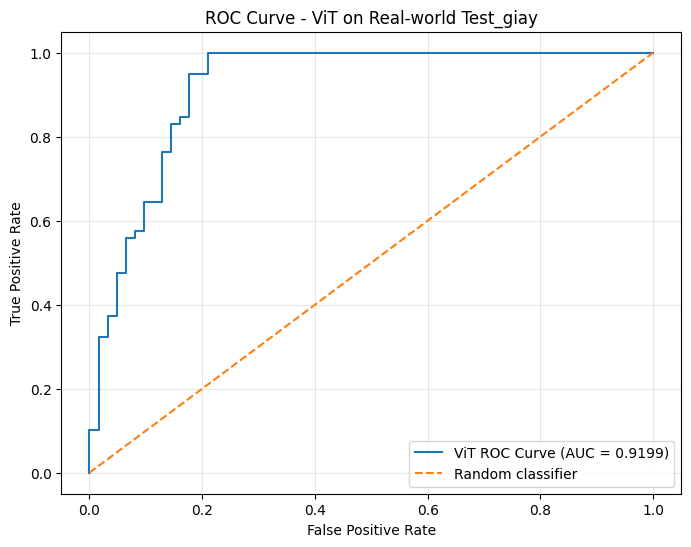

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"ViT ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ViT on Real-world Test_giay")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

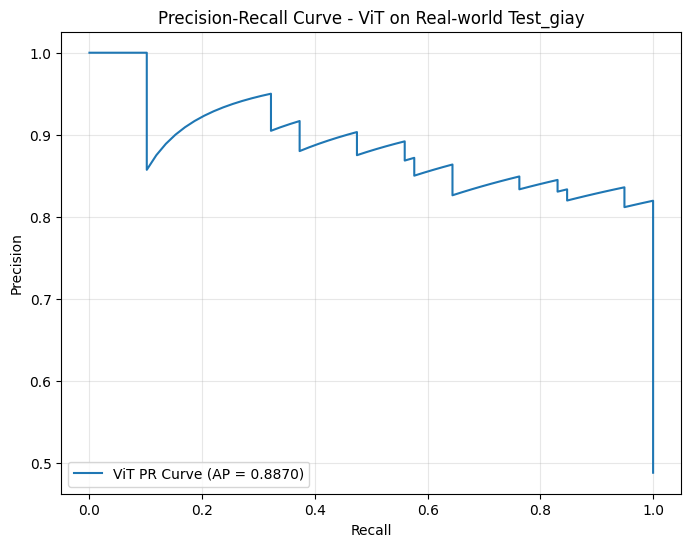

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"ViT PR Curve (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - ViT on Real-world Test_giay")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.show()

#Bổ sung các chỉ số đánh giá

In [ ]:
import os
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    auc,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vit_b_16

print("Import thư viện thành công.")

Import thư viện thành công.


In [ ]:
zip_path = "/content/drive/MyDrive/NCKH2026/code/fake-real-adidas.v4i.folder.zip"
extract_path = "/content/dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Đã giải nén dữ liệu.")

Đã giải nén dữ liệu.


In [ ]:
raw_path = "/content/raw_data"

if os.path.exists(raw_path):
    shutil.rmtree(raw_path)

for label in ["real", "fake"]:
    os.makedirs(os.path.join(raw_path, label), exist_ok=True)

data_records = []

for split_folder in ["train", "test", "valid"]:
    split_dir = os.path.join(extract_path, split_folder)

    if not os.path.exists(split_dir):
        continue

    for label in ["real", "fake"]:
        label_dir = os.path.join(split_dir, label)

        if not os.path.exists(label_dir):
            continue

        for file_name in os.listdir(label_dir):
            src_file = os.path.join(label_dir, file_name)

            if not os.path.isfile(src_file):
                continue

            new_file_name = f"{split_folder}_{file_name}"
            dest_file = os.path.join(raw_path, label, new_file_name)

            shutil.copy(src_file, dest_file)

            data_records.append({
                "image_path": dest_file,
                "label": label
            })

data_raw = pd.DataFrame(data_records)

print("Tổng số ảnh:", len(data_raw))
print(data_raw["label"].value_counts())
display(data_raw.head())

Tổng số ảnh: 1961
label
real    1286
fake     675
Name: count, dtype: int64


,image_path,label
0,/content/raw_data/real/train_00233_jpg.rf.fbe8...,real
1,/content/raw_data/real/train_00283_jpg.rf.40b8...,real
2,/content/raw_data/real/train_00175_jpg.rf.1b18...,real
3,/content/raw_data/real/train_00274_jpg.rf.3ccd...,real
4,/content/raw_data/real/train_00311_jpg.rf.70a3...,real


In [ ]:
train_df, temp_df = train_test_split(
    data_raw,
    test_size=0.3,
    random_state=42,
    stratify=data_raw["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train:", len(train_df))
print("Valid:", len(val_df))
print("Test:", len(test_df))

print("\nPhân bố nhãn trong test_df:")
print(test_df["label"].value_counts())

Train: 1372
Valid: 294
Test: 295

Phân bố nhãn trong test_df:
label
real    193
fake    102
Name: count, dtype: int64


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", test_generator.class_indices)

Found 295 validated image filenames belonging to 2 classes.
Class indices: {'fake': 0, 'real': 1}


In [ ]:
mobilenet_path = "/content/drive/MyDrive/NCKH2026/mobilenetv2_finetuned_best_model.h5"

model_mobilenet = tf.keras.models.load_model(mobilenet_path)

print("Đã load MobileNetV2 thành công.")

Đã load MobileNetV2 thành công.


In [ ]:
resnet_path = "/content/drive/MyDrive/NCKH2026/Best_model/resnet50_best_model.h5"

model_resnet = tf.keras.models.load_model(resnet_path)

print("Đã load ResNet50 thành công.")

Đã load ResNet50 thành công.


In [ ]:
def get_keras_predictions(model, test_generator, model_name):
    test_generator.reset()

    # Với binary sigmoid, model.predict trả xác suất của class index = 1
    prob_class_1 = model.predict(test_generator, verbose=1).ravel()
    prob_class_1 = np.array(prob_class_1)

    y_true = np.array(test_generator.classes).astype(int)

    class_indices = test_generator.class_indices
    fake_index = class_indices["fake"]
    real_index = class_indices["real"]

    if real_index == 1:
        prob_real = prob_class_1
        prob_fake = 1 - prob_real
    else:
        prob_fake = prob_class_1
        prob_real = 1 - prob_fake

    y_pred_real = (prob_real >= 0.5).astype(int)
    y_pred_fake = (prob_fake >= 0.5).astype(int)

    df_pred = pd.DataFrame({
        "model": model_name,
        "image_path": test_generator.filepaths,
        "y_true": y_true,
        "y_true_label": ["fake" if x == fake_index else "real" for x in y_true],
        "prob_real": prob_real,
        "prob_fake": prob_fake,
        "y_pred_real": y_pred_real,
        "y_pred_fake": y_pred_fake
    })

    return df_pred

In [ ]:
df_pred_mobilenet = get_keras_predictions(
    model=model_mobilenet,
    test_generator=test_generator,
    model_name="MobileNetV2"
)

df_pred_resnet = get_keras_predictions(
    model=model_resnet,
    test_generator=test_generator,
    model_name="ResNet50"
)

display(df_pred_mobilenet.head())
display(df_pred_resnet.head())

10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 584ms/step


,model,image_path,y_true,y_true_label,prob_real,prob_fake,y_pred_real,y_pred_fake
0,MobileNetV2,/content/raw_data/fake/train_fake84_jpg.rf.9a0...,0,fake,0.029377,0.970623,0,1
1,MobileNetV2,/content/raw_data/real/train_00249_jpg.rf.d40b...,1,real,0.999115,0.000885,1,0
2,MobileNetV2,/content/raw_data/real/train_real_34_PNG.rf.ab...,1,real,0.922916,0.077084,1,0
3,MobileNetV2,/content/raw_data/real/train_00284_jpg.rf.8580...,1,real,0.999687,0.000313,1,0
4,MobileNetV2,/content/raw_data/real/train_real_19_PNG.rf.1d...,1,real,0.943486,0.056514,1,0


,model,image_path,y_true,y_true_label,prob_real,prob_fake,y_pred_real,y_pred_fake
0,ResNet50,/content/raw_data/fake/train_fake84_jpg.rf.9a0...,0,fake,0.622044,0.377956,1,0
1,ResNet50,/content/raw_data/real/train_00249_jpg.rf.d40b...,1,real,0.771712,0.228288,1,0
2,ResNet50,/content/raw_data/real/train_real_34_PNG.rf.ab...,1,real,0.460696,0.539304,0,1
3,ResNet50,/content/raw_data/real/train_00284_jpg.rf.8580...,1,real,0.763913,0.236087,1,0
4,ResNet50,/content/raw_data/real/train_real_19_PNG.rf.1d...,1,real,0.735014,0.264986,1,0


In [ ]:
IMG_RESIZE = (224, 224)
BATCH_SIZE_VIT = 4
NUM_WORKERS = 0

val_test_transform = transforms.Compose([
    transforms.Resize(IMG_RESIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class ImageDatasetWithPath(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_map = {
            "fake": 0,
            "real": 1
        }

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["image_path"]
        label_str = self.dataframe.iloc[idx]["label"]

        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(self.label_map[label_str], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label, img_path


test_dataset_vit = ImageDatasetWithPath(
    test_df,
    transform=val_test_transform
)

test_loader_vit = DataLoader(
    test_dataset_vit,
    batch_size=BATCH_SIZE_VIT,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Đã tạo test_loader_vit.")

Đã tạo test_loader_vit.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_vit = vit_b_16(weights=None)

# Sửa head giống lúc train
model_vit.heads = nn.Linear(model_vit.heads.head.in_features, 1)

model_vit = model_vit.to(device)

vit_path = "/content/drive/MyDrive/NCKH2026/Best_model/best_vit_model.pth"

state_dict = torch.load(vit_path, map_location=device)
model_vit.load_state_dict(state_dict)

model_vit.eval()

print("Đã load ViT thành công.")

Device: cuda
Đã load ViT thành công.


In [ ]:
#Hàm lấy dự đoán cho PyTorch model
def get_pytorch_predictions(model, dataloader, device, model_name):
    model.eval()

    all_image_paths = []
    all_y_true = []
    all_prob_real = []

    with torch.no_grad():
        for images, labels, image_paths in dataloader:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model(images)

            # Vì ViT output 1 neuron và label real = 1
            prob_real_batch = torch.sigmoid(outputs)

            all_image_paths.extend(list(image_paths))
            all_y_true.extend(labels.cpu().numpy().flatten().astype(int).tolist())
            all_prob_real.extend(prob_real_batch.cpu().numpy().flatten().tolist())

    y_true = np.array(all_y_true).astype(int)
    prob_real = np.array(all_prob_real)

    prob_fake = 1 - prob_real

    y_pred_real = (prob_real >= 0.5).astype(int)
    y_pred_fake = (prob_fake >= 0.5).astype(int)

    df_pred = pd.DataFrame({
        "model": model_name,
        "image_path": all_image_paths,
        "y_true": y_true,
        "y_true_label": ["fake" if x == 0 else "real" for x in y_true],
        "prob_real": prob_real,
        "prob_fake": prob_fake,
        "y_pred_real": y_pred_real,
        "y_pred_fake": y_pred_fake
    })

    return df_pred

In [ ]:
#Chạy dự đoán ViT
df_pred_vit = get_pytorch_predictions(
    model=model_vit,
    dataloader=test_loader_vit,
    device=device,
    model_name="Vision Transformer"
)

display(df_pred_vit.head())

,model,image_path,y_true,y_true_label,prob_real,prob_fake,y_pred_real,y_pred_fake
0,Vision Transformer,/content/raw_data/fake/train_fake84_jpg.rf.9a0...,0,fake,0.324262,0.675738,0,1
1,Vision Transformer,/content/raw_data/real/train_00249_jpg.rf.d40b...,1,real,0.973094,0.026906,1,0
2,Vision Transformer,/content/raw_data/real/train_real_34_PNG.rf.ab...,1,real,0.454329,0.545671,0,1
3,Vision Transformer,/content/raw_data/real/train_00284_jpg.rf.8580...,1,real,0.896838,0.103162,1,0
4,Vision Transformer,/content/raw_data/real/train_real_19_PNG.rf.1d...,1,real,0.426437,0.573563,0,1


In [ ]:
#Gộp dự đoán
df_all_predictions = pd.concat(
    [
        df_pred_mobilenet,
        df_pred_resnet,
        df_pred_vit
    ],
    ignore_index=True
)

display(df_all_predictions.head())
print(df_all_predictions["model"].value_counts())

,model,image_path,y_true,y_true_label,prob_real,prob_fake,y_pred_real,y_pred_fake
0,MobileNetV2,/content/raw_data/fake/train_fake84_jpg.rf.9a0...,0,fake,0.029377,0.970623,0,1
1,MobileNetV2,/content/raw_data/real/train_00249_jpg.rf.d40b...,1,real,0.999115,0.000885,1,0
2,MobileNetV2,/content/raw_data/real/train_real_34_PNG.rf.ab...,1,real,0.922916,0.077084,1,0
3,MobileNetV2,/content/raw_data/real/train_00284_jpg.rf.8580...,1,real,0.999687,0.000313,1,0
4,MobileNetV2,/content/raw_data/real/train_real_19_PNG.rf.1d...,1,real,0.943486,0.056514,1,0


model
MobileNetV2           295
ResNet50              295
Vision Transformer    295
Name: count, dtype: int64


In [ ]:
#Lưu lại bảng xác suất dự đoán
#prediction_save_path = "/content/drive/MyDrive/NCKH2026/predictions_3_models_extra_metrics.csv"

df_all_predictions.to_csv(
    prediction_save_path,
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu bảng dự đoán tại:", prediction_save_path)

Đã lưu bảng dự đoán tại: /content/drive/MyDrive/NCKH2026/predictions_3_models_extra_metrics.csv


#Tính AUC-ROC, PR-Curve, KS, G-mean

In [ ]:
#Hàm tính tất cả chỉ số
def calculate_all_metrics(df_pred, model_name):
    # Fake là positive class
    y_true = df_pred["y_true"].values.astype(int)
    y_true_fake = (y_true == 0).astype(int)

    prob_fake = df_pred["prob_fake"].values.astype(float)
    y_pred_fake = df_pred["y_pred_fake"].values.astype(int)

    accuracy = accuracy_score(y_true_fake, y_pred_fake)
    precision_fake = precision_score(y_true_fake, y_pred_fake, zero_division=0)
    recall_fake = recall_score(y_true_fake, y_pred_fake, zero_division=0)
    f1_fake = f1_score(y_true_fake, y_pred_fake, zero_division=0)

    roc_auc = roc_auc_score(y_true_fake, prob_fake)
    fpr, tpr, roc_thresholds = roc_curve(y_true_fake, prob_fake)

    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
        y_true_fake,
        prob_fake
    )

    average_precision = average_precision_score(y_true_fake, prob_fake)
    pr_auc = auc(recall_curve, precision_curve)

    ks_values = tpr - fpr
    ks_statistic = np.max(ks_values)
    best_threshold_ks = roc_thresholds[np.argmax(ks_values)]

    tn, fp, fn, tp = confusion_matrix(y_true_fake, y_pred_fake).ravel()

    sensitivity_fake = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity_real = tn / (tn + fp) if (tn + fp) > 0 else 0

    gmean_05 = np.sqrt(sensitivity_fake * specificity_real)

    gmeans = np.sqrt(tpr * (1 - fpr))
    best_gmean = np.max(gmeans)
    best_threshold_gmean = roc_thresholds[np.argmax(gmeans)]

    result = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision_Fake": precision_fake,
        "Recall_Fake": recall_fake,
        "F1_Fake": f1_fake,
        "ROC_AUC": roc_auc,
        "Average_Precision": average_precision,
        "PR_AUC": pr_auc,
        "KS_Statistic": ks_statistic,
        "Sensitivity_Fake": sensitivity_fake,
        "Specificity_Real": specificity_real,
        "G_mean_threshold_0_5": gmean_05,
        "Best_G_mean": best_gmean,
        "Best_threshold_KS": best_threshold_ks,
        "Best_threshold_G_mean": best_threshold_gmean,
        "TP_Fake": tp,
        "FN_Fake_as_Real": fn,
        "FP_Real_as_Fake": fp,
        "TN_Real": tn
    }

    curve_data = {
        "fpr": fpr,
        "tpr": tpr,
        "roc_thresholds": roc_thresholds,
        "precision_curve": precision_curve,
        "recall_curve": recall_curve,
        "pr_thresholds": pr_thresholds,
        "gmeans": gmeans
    }

    return result, curve_data

In [ ]:
#Tính chỉ số cho 3 mô hình
results = []
curve_dict = {}

for model_name, df_model in df_all_predictions.groupby("model"):
    result, curve_data = calculate_all_metrics(df_model, model_name)
    results.append(result)
    curve_dict[model_name] = curve_data

df_metrics = pd.DataFrame(results)

df_metrics = df_metrics.sort_values(
    by=["Recall_Fake", "Average_Precision", "G_mean_threshold_0_5", "ROC_AUC"],
    ascending=False
)

display(df_metrics)

,Model,Accuracy,Precision_Fake,Recall_Fake,F1_Fake,ROC_AUC,Average_Precision,PR_AUC,KS_Statistic,Sensitivity_Fake,Specificity_Real,G_mean_threshold_0_5,Best_G_mean,Best_threshold_KS,Best_threshold_G_mean,TP_Fake,FN_Fake_as_Real,FP_Real_as_Fake,TN_Real
2,Vision Transformer,0.915254,0.881188,0.872549,0.876847,0.973077,0.934212,0.933526,0.868079,0.872549,0.937824,0.904598,0.933886,0.446238,0.446238,89,13,12,181
0,MobileNetV2,0.888136,0.960000,0.705882,0.813559,0.982322,0.957498,0.957118,0.901554,0.705882,0.984456,0.833613,0.949502,0.026652,0.026652,72,30,3,190
1,ResNet50,0.691525,0.703704,0.186275,0.294574,0.666311,0.554716,0.551772,0.314183,0.186275,0.958549,0.422556,0.652366,0.286924,0.286924,19,83,8,185


In [ ]:
#Lưu bảng kết quả đầy đủ
metrics_save_path = "/content/drive/MyDrive/NCKH2026/extra_metrics_3_models_full.csv"

df_metrics.to_csv(
    metrics_save_path,
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu bảng chỉ số đầy đủ tại:", metrics_save_path)

Đã lưu bảng chỉ số đầy đủ tại: /content/drive/MyDrive/NCKH2026/extra_metrics_3_models_full.csv


In [ ]:
#Tạo bảng gọn để đưa vào bài báo
df_table_for_paper = df_metrics[
    [
        "Model",
        "Accuracy",
        "Precision_Fake",
        "Recall_Fake",
        "F1_Fake",
        "ROC_AUC",
        "Average_Precision",
        "PR_AUC",
        "KS_Statistic",
        "G_mean_threshold_0_5"
    ]
].copy()

for col in df_table_for_paper.columns:
    if col != "Model":
        df_table_for_paper[col] = df_table_for_paper[col].round(4)

display(df_table_for_paper)

,Model,Accuracy,Precision_Fake,Recall_Fake,F1_Fake,ROC_AUC,Average_Precision,PR_AUC,KS_Statistic,G_mean_threshold_0_5
2,Vision Transformer,0.9153,0.8812,0.8725,0.8768,0.9731,0.9342,0.9335,0.8681,0.9046
0,MobileNetV2,0.8881,0.9600,0.7059,0.8136,0.9823,0.9575,0.9571,0.9016,0.8336
1,ResNet50,0.6915,0.7037,0.1863,0.2946,0.6663,0.5547,0.5518,0.3142,0.4226


In [ ]:
paper_table_path = "/content/drive/MyDrive/NCKH2026/table_extra_metrics_for_paper.csv"

df_table_for_paper.to_csv(
    paper_table_path,
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu bảng dùng cho bài báo tại:", paper_table_path)

Đã lưu bảng dùng cho bài báo tại: /content/drive/MyDrive/NCKH2026/table_extra_metrics_for_paper.csv


In classification report và confusion matrix



In [ ]:
#In báo cáo chi tiết từng mô hình
for model_name, df_model in df_all_predictions.groupby("model"):
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    y_true = df_model["y_true"].values.astype(int)
    y_true_fake = (y_true == 0).astype(int)
    y_pred_fake = df_model["y_pred_fake"].values.astype(int)

    print("Classification report, Fake is positive class:")
    print(classification_report(
        y_true_fake,
        y_pred_fake,
        target_names=["Real", "Fake"],
        digits=4
    ))

    print("Confusion matrix:")
    print(confusion_matrix(y_true_fake, y_pred_fake))
    print("\n")

MobileNetV2
Classification report, Fake is positive class:
              precision    recall  f1-score   support

        Real     0.8636    0.9845    0.9201       193
        Fake     0.9600    0.7059    0.8136       102

    accuracy                         0.8881       295
   macro avg     0.9118    0.8452    0.8668       295
weighted avg     0.8970    0.8881    0.8833       295

Confusion matrix:
[[190   3]
 [ 30  72]]


ResNet50
Classification report, Fake is positive class:
              precision    recall  f1-score   support

        Real     0.6903    0.9585    0.8026       193
        Fake     0.7037    0.1863    0.2946       102

    accuracy                         0.6915       295
   macro avg     0.6970    0.5724    0.5486       295
weighted avg     0.6949    0.6915    0.6269       295

Confusion matrix:
[[185   8]
 [ 83  19]]


Vision Transformer
Classification report, Fake is positive class:
              precision    recall  f1-score   support

        Real     0.9330 

#Vẽ ROC Curve

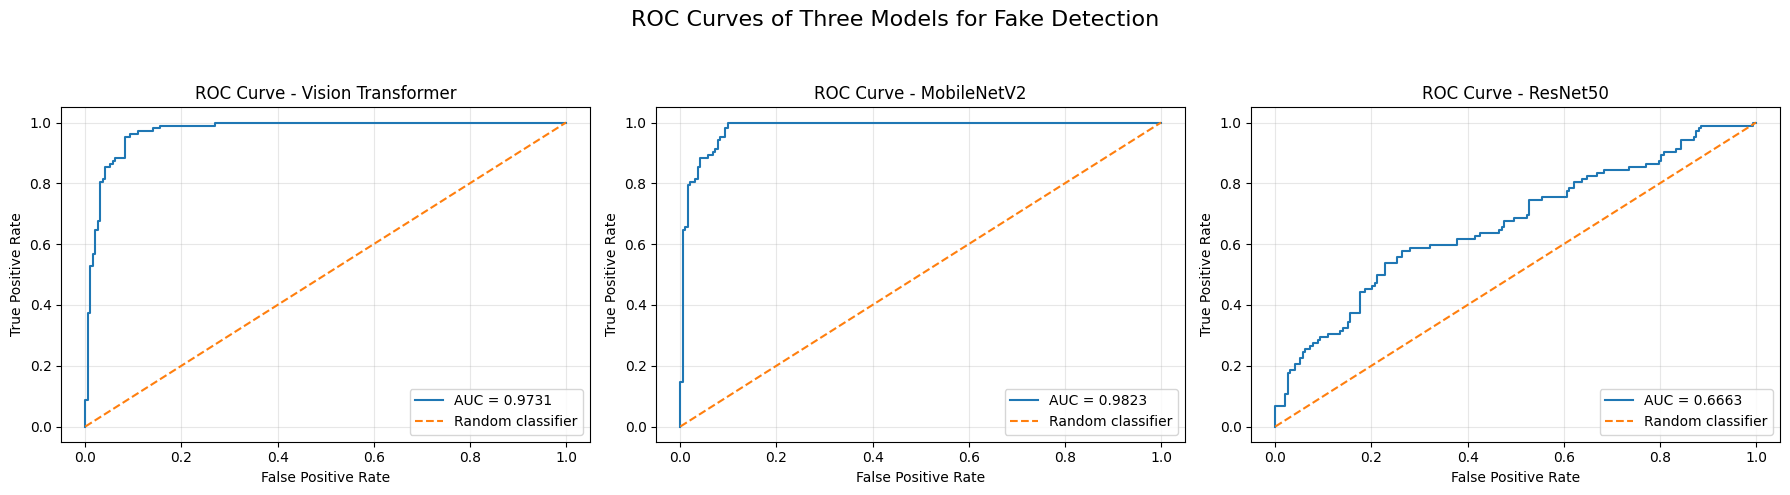

Đã lưu ROC Curve tại: /content/drive/MyDrive/NCKH2026/roc_curve_3_models_one_row.png


In [ ]:
# ROC Curve: 3 mô hình trên 1 hàng

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (_, row) in zip(axes, df_metrics.iterrows()):
    model_name = row["Model"]
    fpr = curve_dict[model_name]["fpr"]
    tpr = curve_dict[model_name]["tpr"]
    roc_auc = row["ROC_AUC"]

    ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

    ax.set_title(f"ROC Curve - {model_name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

plt.suptitle("ROC Curves of Three Models for Fake Detection", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])

roc_save_path = "/content/drive/MyDrive/NCKH2026/roc_curve_3_models_one_row.png"

plt.savefig(
    roc_save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu ROC Curve tại:", roc_save_path)

PR-Curve của 3 mô hình

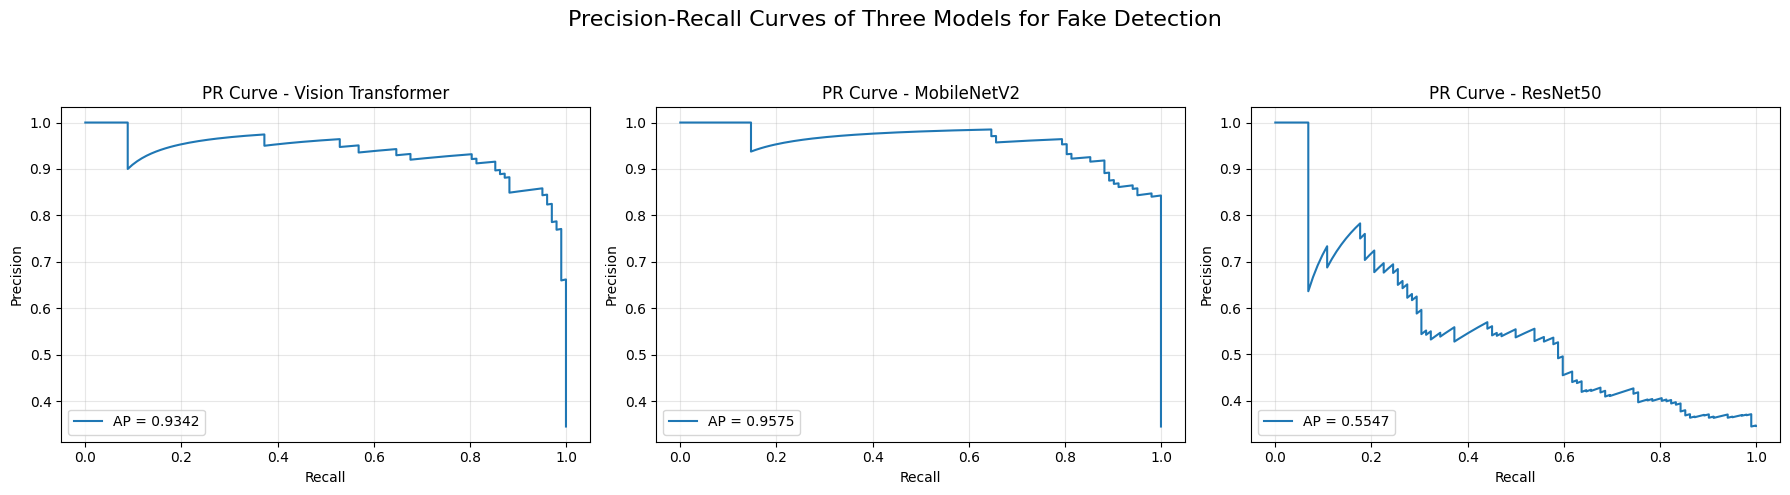

Đã lưu PR-Curve tại: /content/drive/MyDrive/NCKH2026/pr_curve_3_models_one_row.png


In [ ]:
# PR-Curve: 3 mô hình trên 1 hàng

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (_, row) in zip(axes, df_metrics.iterrows()):
    model_name = row["Model"]
    precision_curve = curve_dict[model_name]["precision_curve"]
    recall_curve = curve_dict[model_name]["recall_curve"]
    ap = row["Average_Precision"]

    ax.plot(recall_curve, precision_curve, label=f"AP = {ap:.4f}")

    ax.set_title(f"PR Curve - {model_name}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(loc="lower left")
    ax.grid(alpha=0.3)

plt.suptitle("Precision-Recall Curves of Three Models for Fake Detection", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])

pr_save_path = "/content/drive/MyDrive/NCKH2026/pr_curve_3_models_one_row.png"

plt.savefig(
    pr_save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu PR-Curve tại:", pr_save_path)

KS Curve cho từng mô hình

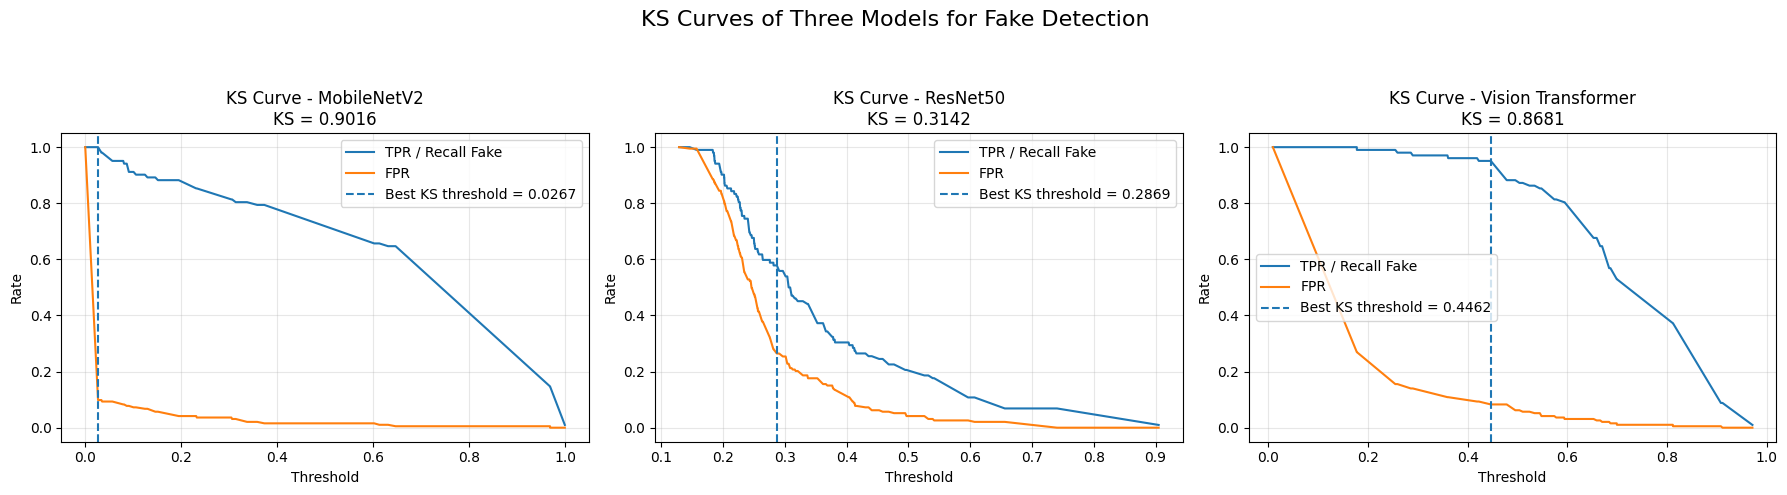

Đã lưu KS Curve tại: /content/drive/MyDrive/NCKH2026/ks_curve_3_models_one_row.png


In [ ]:
# KS Curve: 3 mô hình trên 1 hàng

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, curve_dict.keys()):
    fpr = curve_dict[model_name]["fpr"]
    tpr = curve_dict[model_name]["tpr"]
    thresholds = curve_dict[model_name]["roc_thresholds"]

    ks_values = tpr - fpr
    ks_statistic = np.max(ks_values)
    best_threshold = thresholds[np.argmax(ks_values)]

    ax.plot(thresholds, tpr, label="TPR / Recall Fake")
    ax.plot(thresholds, fpr, label="FPR")

    ax.axvline(
        best_threshold,
        linestyle="--",
        label=f"Best KS threshold = {best_threshold:.4f}"
    )

    ax.set_title(f"KS Curve - {model_name}\nKS = {ks_statistic:.4f}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Rate")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("KS Curves of Three Models for Fake Detection", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.92])

ks_save_path = "/content/drive/MyDrive/NCKH2026/ks_curve_3_models_one_row.png"

plt.savefig(
    ks_save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu KS Curve tại:", ks_save_path)